# Setup & Libraries

In [1]:
!pip install thop umap-learn

import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from thop import profile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dir = '//kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/train'
test_dir = '/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test'

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

ssl_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=base_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.0 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

2026-06-21 15:26:18.352007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782055578.518022      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782055578.570662      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782055578.976863      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782055578.976900      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782055578.976903      58 computation_placer.cc:177] computation placer alr

# SimCLR Architecture & Loss

In [2]:
class SimCLR_DenseNet(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.encoder = models.densenet121(weights=None)
        dim_mlp = self.encoder.classifier.in_features
        self.encoder.classifier = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(dim_mlp, dim_mlp),
            nn.ReLU(),
            nn.Linear(dim_mlp, out_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z

def nt_xent_loss(z1, z2, temperature=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    batch_size = z1.shape[0]
    representations = torch.cat([z1, z2], dim=0)
    similarity_matrix = F.cosine_similarity(representations.unsqueeze(1), representations.unsqueeze(0), dim=2)
    mask = torch.eye(batch_size * 2, dtype=torch.bool).to(z1.device)
    labels = torch.cat([torch.arange(batch_size) for _ in range(2)], dim=0).to(z1.device)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
    labels = labels[~mask].view(labels.shape[0], -1)
    similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)
    positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)
    negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)
    logits = torch.cat([positives, negatives], dim=1) / temperature
    labels = torch.zeros(logits.shape[0], dtype=torch.long).to(z1.device)
    return F.cross_entropy(logits, labels)

# Pretraining & Learning Curve

Epoch [1/10], Loss: 3.1861
Epoch [2/10], Loss: 2.8688
Epoch [3/10], Loss: 2.5701
Epoch [4/10], Loss: 2.4158
Epoch [5/10], Loss: 2.3509
Epoch [6/10], Loss: 2.2651
Epoch [7/10], Loss: 2.2087
Epoch [8/10], Loss: 2.1753
Epoch [9/10], Loss: 2.1077
Epoch [10/10], Loss: 2.0928

Pretraining Time: 1311.75 seconds


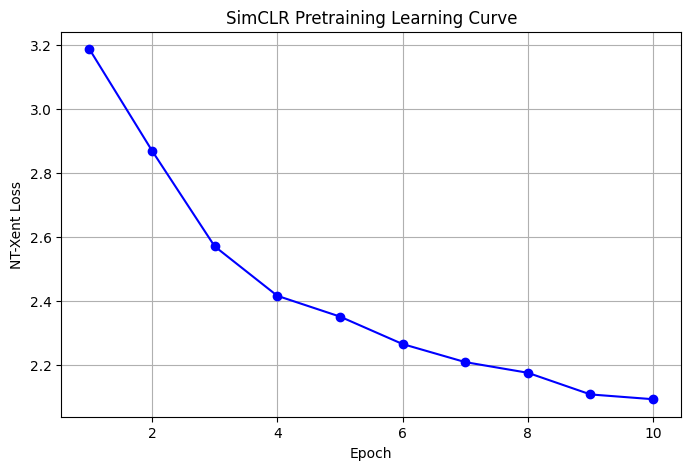

In [3]:
model = SimCLR_DenseNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0003)
scaler = torch.amp.GradScaler('cuda')

epochs = 10
pretrain_losses = []
start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, _ in train_loader:
        torch.cuda.empty_cache()
        img1 = torch.stack([ssl_transform(transforms.ToPILImage()(img)) for img in images]).to(device)
        img2 = torch.stack([ssl_transform(transforms.ToPILImage()(img)) for img in images]).to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            _, z1 = model(img1)
            _, z2 = model(img2)
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print(f"\nPretraining Time: {time.time() - start_time:.2f} seconds")
torch.save(model.state_dict(), 'simclr_frozen_encoder.pth')

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), pretrain_losses, marker='o', color='blue')
plt.title('SimCLR Pretraining Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.grid(True)
plt.show()

# Feature Extraction & Embeddings

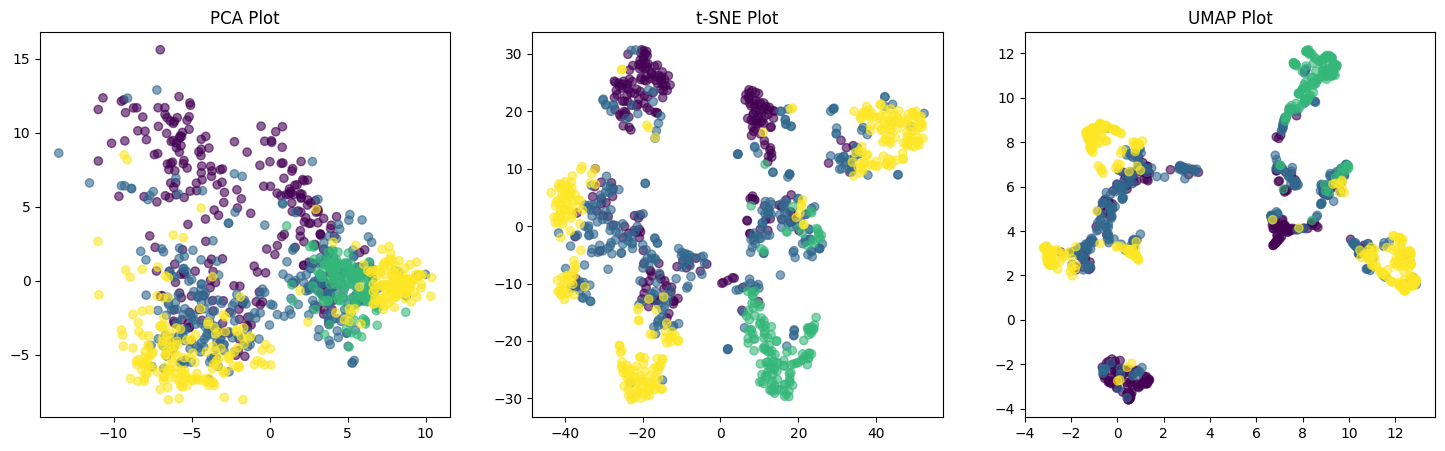

Silhouette Score (t-SNE): 0.0323


In [4]:
def extract_features(model, dataloader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            h, _ = model(imgs)
            features.append(h.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)

X_train, y_train = extract_features(model, train_loader)
X_test, y_test = extract_features(model, test_loader)

pca_res = PCA(n_components=2).fit_transform(X_test)
tsne_res = TSNE(n_components=2, perplexity=30).fit_transform(X_test)
umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X_test)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(pca_res[:, 0], pca_res[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.title('PCA Plot')
plt.subplot(1, 3, 2)
plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.title('t-SNE Plot')
plt.subplot(1, 3, 3)
plt.scatter(umap_res[:, 0], umap_res[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.title('UMAP Plot')
plt.show()

print(f"Silhouette Score (t-SNE): {silhouette_score(tsne_res, y_test):.4f}")

# Shallow Heads & Fine-Tuning

In [5]:
start_train = time.time()
lp_model = MLPClassifier(hidden_layer_sizes=(), max_iter=1000)
lp_model.fit(X_train, y_train)
print(f"Linear Probe Train Time: {time.time() - start_train:.4f} sec")

start_test = time.time()
y_pred_lp = lp_model.predict(X_test)
y_prob_lp = lp_model.predict_proba(X_test)
print(f"Linear Probe Test Time: {time.time() - start_test:.4f} sec\n")

shallow_heads = {
    "Linear Probe": lp_model,
    "MLP (1-Layer)": MLPClassifier(hidden_layer_sizes=(512,), max_iter=1000).fit(X_train, y_train),
    "SVM": SVC(probability=True).fit(X_train, y_train),
    "Decision Tree": DecisionTreeClassifier().fit(X_train, y_train),
    "Random Forest": RandomForestClassifier().fit(X_train, y_train)
}

for name, clf in shallow_heads.items():
    pred = clf.predict(X_test)
    print(f"{name} -> Acc: {accuracy_score(y_test, pred):.4f}, F1: {f1_score(y_test, pred, average='weighted'):.4f}")

class FineTuneModel(nn.Module):
    def __init__(self, base_encoder, num_classes):
        super().__init__()
        self.encoder = base_encoder
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        return self.classifier(h)

ft_model = FineTuneModel(copy.deepcopy(model.encoder), len(train_dataset.classes)).to(device)
optimizer_ft = optim.Adam(ft_model.parameters(), lr=1e-5)
criterion_ft = nn.CrossEntropyLoss()

for epoch in range(5):
    ft_model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        loss = criterion_ft(ft_model(imgs), lbls)
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
    print(f"Fine-tuning Epoch {epoch+1}/5 complete.")

ft_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        _, predicted = torch.max(ft_model(imgs).data, 1)
        total += lbls.size(0)
        correct += (predicted == lbls).sum().item()

print(f"\nFull Fine-tuning Accuracy: {100 * correct / total:.2f}%")

Linear Probe Train Time: 5.9149 sec
Linear Probe Test Time: 0.0034 sec

Linear Probe -> Acc: 0.8920, F1: 0.8915
MLP (1-Layer) -> Acc: 0.9570, F1: 0.9570
SVM -> Acc: 0.8370, F1: 0.8346
Decision Tree -> Acc: 0.8700, F1: 0.8696
Random Forest -> Acc: 0.9130, F1: 0.9117
Fine-tuning Epoch 1/5 complete.
Fine-tuning Epoch 2/5 complete.
Fine-tuning Epoch 3/5 complete.
Fine-tuning Epoch 4/5 complete.
Fine-tuning Epoch 5/5 complete.

Full Fine-tuning Accuracy: 87.40%


# All Detailed Metrics & Graphs

k-NN (k=1) Accuracy: 0.9430
k-NN (k=5) Accuracy: 0.8580
k-NN (k=20) Accuracy: 0.7940

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.80      0.87       254
  meningioma       0.82      0.86      0.84       306
    no_tumor       0.86      0.97      0.91       140
   pituitary       0.95      0.96      0.96       300

    accuracy                           0.89      1000
   macro avg       0.89      0.90      0.89      1000
weighted avg       0.90      0.89      0.89      1000



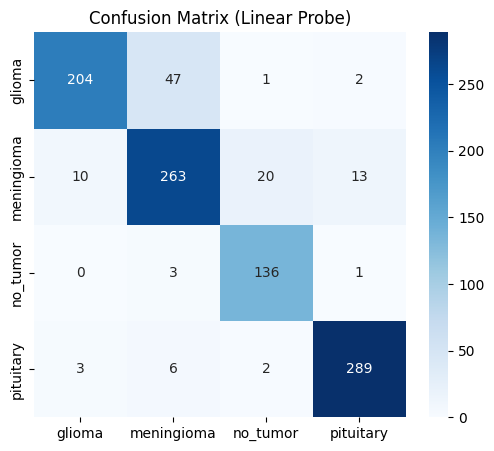

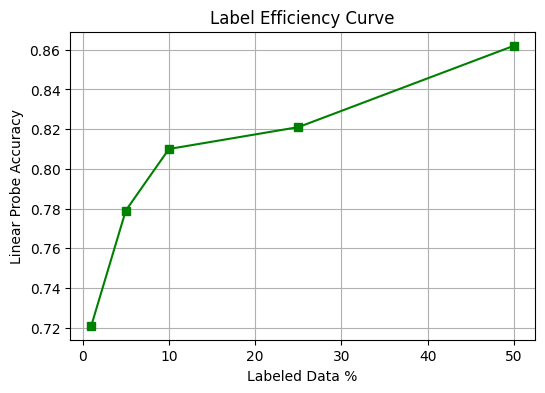

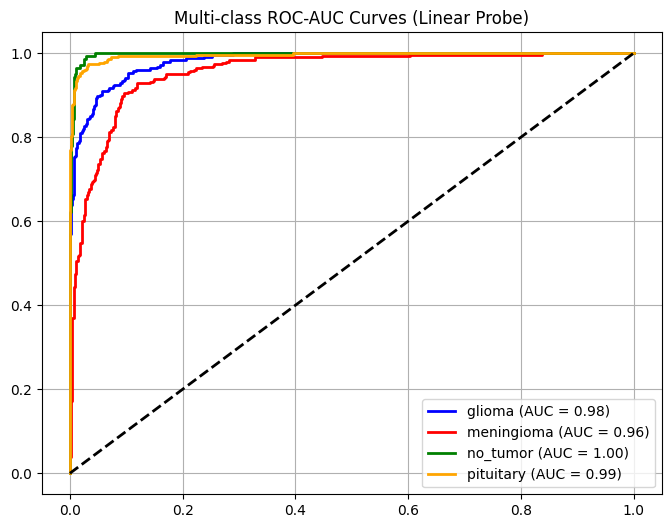


GFLOPs: 2.8960


In [6]:
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f"k-NN (k={k}) Accuracy: {knn.score(X_test, y_test):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lp, target_names=train_dataset.classes))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lp), annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap="Blues")
plt.title("Confusion Matrix (Linear Probe)")
plt.show()

def label_efficiency_curve(percentages):
    eff_accs = []
    for p in percentages:
        n = max(1, int(len(X_train) * (p / 100)))
        idx = np.random.choice(len(X_train), n, replace=False)
        lp = MLPClassifier(hidden_layer_sizes=(), max_iter=2000).fit(X_train[idx], y_train[idx])
        eff_accs.append(lp.score(X_test, y_test))
    return eff_accs

p_list = [1, 5, 10, 25, 50]
plt.figure(figsize=(6, 4))
plt.plot(p_list, label_efficiency_curve(p_list), marker='s', color='green')
plt.title("Label Efficiency Curve")
plt.xlabel("Labeled Data %")
plt.ylabel("Linear Probe Accuracy")
plt.grid(True)
plt.show()

classes_list = list(range(len(train_dataset.classes)))
y_test_bin = label_binarize(y_test, classes=classes_list)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lp[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{train_dataset.classes[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC-AUC Curves (Linear Probe)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

input_dummy = torch.randn(1, 3, 224, 224).to(device)
macs, params = profile(model.encoder, inputs=(input_dummy,), verbose=False)
print(f"\nGFLOPs: {macs / 1e9:.4f}")